In [24]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [25]:
raw_dir = Path("../data/raw")

nav_file = list(raw_dir.glob("*nav_history*.csv"))[0]

nav_df = pd.read_csv(nav_file)

nav_df["date"] = pd.to_datetime(nav_df["date"], errors="coerce")

nav_df = nav_df.sort_values(["amfi_code", "date"])

print("NAV data loaded successfully!")
print("Shape:", nav_df.shape)
print("Columns:", nav_df.columns.tolist())
print("Number of schemes:", nav_df["amfi_code"].nunique())
print("Date range:", nav_df["date"].min(), "to", nav_df["date"].max())

nav_df.head()

NAV data loaded successfully!
Shape: (46000, 3)
Columns: ['amfi_code', 'date', 'nav']
Number of schemes: 40
Date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00


,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [26]:
# Calculate daily returns for all 40 schemes

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"].pct_change()
)

print("Daily returns calculated successfully!")

print("Total rows:", len(nav_df))
print("Missing daily returns:", nav_df["daily_return"].isna().sum())

print("\nDaily Return Summary:")
print(nav_df["daily_return"].describe())

nav_df.head(10)

Daily returns calculated successfully!
Total rows: 46000
Missing daily returns: 40

Daily Return Summary:
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


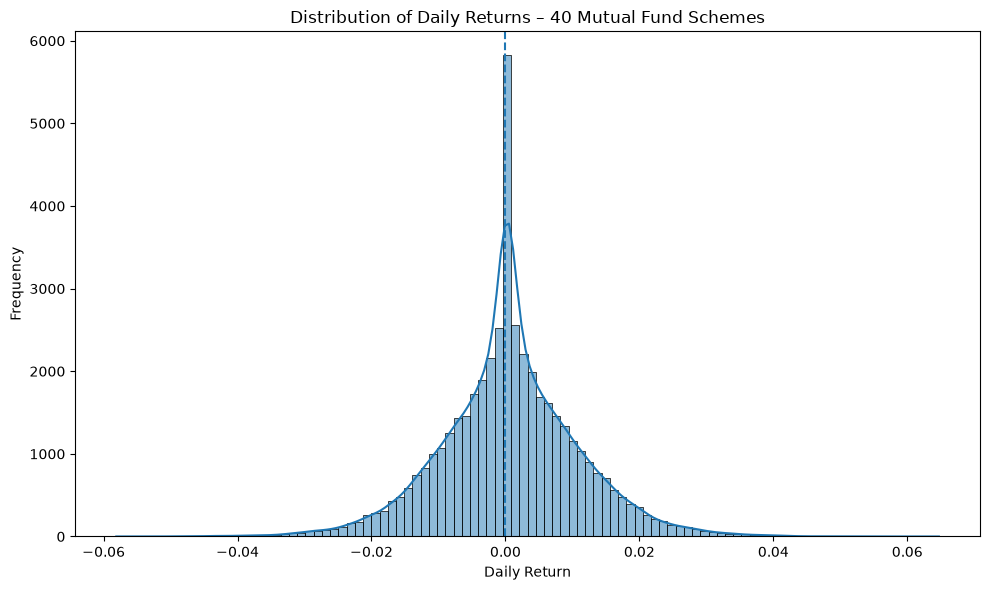

In [27]:
plt.figure(figsize=(10, 6))

sns.histplot(
    nav_df["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns – 40 Mutual Fund Schemes")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.axvline(0, linestyle="--")

plt.tight_layout()
plt.show()

In [28]:
# Calculate CAGR for 1-year, 3-year and 5-year periods

latest_date = nav_df["date"].max()

periods = {
    "1Y": 1,
    "3Y": 3,
    "5Y": 5
}

cagr_results = []

for amfi_code, fund_data in nav_df.groupby("amfi_code"):

    fund_data = fund_data.sort_values("date")

    latest_row = fund_data.iloc[-1]
    latest_nav = latest_row["nav"]
    latest_fund_date = latest_row["date"]

    result = {
        "amfi_code": amfi_code,
        "latest_date": latest_fund_date,
        "latest_nav": latest_nav
    }

    for period_name, years in periods.items():

        target_date = latest_fund_date - pd.DateOffset(years=years)

        previous_data = fund_data[fund_data["date"] <= target_date]

        if len(previous_data) > 0:
            start_row = previous_data.iloc[-1]
            start_nav = start_row["nav"]

            cagr = (latest_nav / start_nav) ** (1 / years) - 1

            result[f"CAGR_{period_name}"] = cagr
        else:
            result[f"CAGR_{period_name}"] = np.nan

    cagr_results.append(result)

cagr_df = pd.DataFrame(cagr_results)

print("CAGR calculation completed!")
print("Number of funds:", len(cagr_df))

cagr_df.head(10)

CAGR calculation completed!
Number of funds: 40


,amfi_code,latest_date,latest_nav,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,2026-05-29,583.6113,-0.022243,0.012926,NaN
1,100025,2026-05-29,31.8843,0.037050,0.039164,NaN
2,100033,2026-05-29,342.0072,0.532324,0.324425,NaN
3,101206,2026-05-29,773.2939,0.479241,0.289677,NaN
4,101207,2026-05-29,53.9836,-0.239860,-0.041524,NaN
5,101208,2026-05-29,410.1021,0.072366,0.063158,NaN
6,102885,2026-05-29,187.7797,0.202077,0.196673,NaN
7,102886,2026-05-29,125.5640,-0.167975,-0.007674,NaN
8,102887,2026-05-29,378.9657,0.135831,0.255562,NaN
9,118632,2026-05-29,110.5554,0.339810,0.226524,NaN


In [29]:
# Convert CAGR values from decimal to percentage

cagr_df["CAGR_1Y_pct"] = cagr_df["CAGR_1Y"] * 100
cagr_df["CAGR_3Y_pct"] = cagr_df["CAGR_3Y"] * 100
cagr_df["CAGR_5Y_pct"] = cagr_df["CAGR_5Y"] * 100

# Display comparison table
cagr_comparison = cagr_df[
    [
        "amfi_code",
        "CAGR_1Y_pct",
        "CAGR_3Y_pct",
        "CAGR_5Y_pct"
    ]
].copy()

cagr_comparison = cagr_comparison.round(2)

print("CAGR comparison table created!")
print("Funds:", len(cagr_comparison))

cagr_comparison

CAGR comparison table created!
Funds: 40


,amfi_code,CAGR_1Y_pct,CAGR_3Y_pct,CAGR_5Y_pct
0,100016,-2.22,1.29,NaN
1,100025,3.70,3.92,NaN
2,100033,53.23,32.44,NaN
3,101206,47.92,28.97,NaN
4,101207,-23.99,-4.15,NaN
5,101208,7.24,6.32,NaN
6,102885,20.21,19.67,NaN
7,102886,-16.80,-0.77,NaN
8,102887,13.58,25.56,NaN
9,118632,33.98,22.65,NaN


In [30]:
# Sharpe Ratio calculation

RISK_FREE_ANNUAL = 0.065
TRADING_DAYS = 252

# Convert annual risk-free rate to daily rate
risk_free_daily = (1 + RISK_FREE_ANNUAL) ** (1 / TRADING_DAYS) - 1

sharpe_results = []

for amfi_code, fund_data in nav_df.groupby("amfi_code"):

    returns = fund_data["daily_return"].dropna()

    # Daily excess return
    excess_returns = returns - risk_free_daily

    # Annualized Sharpe Ratio
    sharpe_ratio = (
        excess_returns.mean() / returns.std()
    ) * np.sqrt(TRADING_DAYS)

    sharpe_results.append({
        "amfi_code": amfi_code,
        "sharpe_ratio": sharpe_ratio
    })

sharpe_df = pd.DataFrame(sharpe_results)

# Rank funds: highest Sharpe = Rank 1
sharpe_df["sharpe_rank"] = (
    sharpe_df["sharpe_ratio"]
    .rank(ascending=False, method="min")
    .astype(int)
)

sharpe_df = sharpe_df.sort_values("sharpe_rank")

print("Sharpe Ratio calculation completed!")
print("Number of funds:", len(sharpe_df))

sharpe_df.head(10)

Sharpe Ratio calculation completed!
Number of funds: 40


,amfi_code,sharpe_ratio,sharpe_rank
34,148567,1.462504,1
30,120843,1.319442,2
36,148569,1.246344,3
19,119551,1.222947,4
25,120505,1.190559,5
38,149323,1.143490,6
2,100033,1.104352,7
9,118632,1.095918,8
3,101206,1.041061,9
24,120504,1.040569,10


In [31]:
# Sortino Ratio calculation

sortino_results = []

for amfi_code, fund_data in nav_df.groupby("amfi_code"):

    returns = fund_data["daily_return"].dropna()

    # Negative returns only
    downside_returns = returns[returns < 0]

    # Downside deviation
    downside_std = downside_returns.std()

    # Annualized Sortino Ratio
    sortino_ratio = (
        (returns.mean() - risk_free_daily) / downside_std
    ) * np.sqrt(TRADING_DAYS)

    sortino_results.append({
        "amfi_code": amfi_code,
        "sortino_ratio": sortino_ratio
    })

sortino_df = pd.DataFrame(sortino_results)

# Rank: highest Sortino = Rank 1
sortino_df["sortino_rank"] = (
    sortino_df["sortino_ratio"]
    .rank(ascending=False, method="min")
    .astype(int)
)

sortino_df = sortino_df.sort_values("sortino_rank")

print("Sortino Ratio calculation completed!")
print("Number of funds:", len(sortino_df))

sortino_df.head(10)

Sortino Ratio calculation completed!
Number of funds: 40


,amfi_code,sortino_ratio,sortino_rank
34,148567,2.409056,1
30,120843,2.387295,2
36,148569,2.166757,3
19,119551,2.166272,4
25,120505,2.047336,5
27,120507,1.918995,6
38,149323,1.893929,7
9,118632,1.874521,8
2,100033,1.846950,9
24,120504,1.829993,10


In [32]:
# Load benchmark index data

benchmark_file = list(raw_dir.glob("*benchmark_indices*.csv"))[0]

benchmark_df = pd.read_csv(benchmark_file)

benchmark_df["date"] = pd.to_datetime(
    benchmark_df["date"],
    errors="coerce"
)

print("Benchmark data loaded successfully!")
print("Shape:", benchmark_df.shape)
print("Columns:", benchmark_df.columns.tolist())

print("\nAvailable indices:")
print(benchmark_df["index_name"].unique())

benchmark_df.head()

Benchmark data loaded successfully!
Shape: (8050, 3)
Columns: ['date', 'index_name', 'close_value']

Available indices:
<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [33]:
# Prepare NIFTY 100 benchmark returns

nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

nifty100 = nifty100.dropna(
    subset=["benchmark_return"]
)

print("NIFTY 100 returns calculated!")
print("Rows:", len(nifty100))
print("Date range:", nifty100["date"].min(), "to", nifty100["date"].max())

print("\nBenchmark return summary:")
print(nifty100["benchmark_return"].describe())

nifty100.head()

NIFTY 100 returns calculated!
Rows: 1149
Date range: 2022-01-04 00:00:00 to 2026-05-29 00:00:00

Benchmark return summary:
count    1149.000000
mean        0.000122
std         0.008119
min        -0.026873
25%        -0.005385
50%        -0.000112
75%         0.005456
max         0.026795
Name: benchmark_return, dtype: float64


,date,index_name,close_value,benchmark_return
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150
1155,2022-01-10,NIFTY100,17516.51,-0.008351


In [34]:
from scipy.stats import linregress

alpha_beta_results = []

for amfi_code, fund_data in nav_df.groupby("amfi_code"):

    # Fund daily returns
    fund_returns = fund_data[
        ["date", "daily_return"]
    ].dropna()

    # Match fund returns with NIFTY 100 returns by date
    merged = pd.merge(
        fund_returns,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    # OLS regression:
    # Fund Return = Alpha + Beta × NIFTY100 Return
    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = regression.slope

    # Annualized alpha
    alpha = regression.intercept * TRADING_DAYS

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "alpha": alpha,
        "beta": beta,
        "r_squared": regression.rvalue ** 2
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

print("Alpha & Beta calculation completed!")
print("Number of funds:", len(alpha_beta_df))

alpha_beta_df.head(10)

Alpha & Beta calculation completed!
Number of funds: 40


,amfi_code,alpha,beta,r_squared
0,100016,0.037476,-0.058268,0.002665
1,100025,0.042818,0.001158,0.000015
2,100033,0.271954,0.005104,0.000012
3,101206,0.213998,0.021086,0.000348
4,101207,0.108971,-0.065289,0.001064
5,101208,0.060861,0.000267,0.000046
6,102885,0.170488,-0.019487,0.000383
7,102886,0.028969,-0.042125,0.000896
8,102887,0.162113,0.016683,0.000186
9,118632,0.218294,-0.008354,0.000058


In [35]:
from scipy.stats import linregress

alpha_beta_results = []

for amfi_code, fund_data in nav_df.groupby("amfi_code"):

    # Fund daily returns
    fund_returns = fund_data[
        ["date", "daily_return"]
    ].dropna()

    # Match fund returns with NIFTY 100 returns by date
    merged = pd.merge(
        fund_returns,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    # OLS regression:
    # Fund Return = Alpha + Beta × NIFTY100 Return
    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = regression.slope

    # Annualized alpha
    alpha = regression.intercept * TRADING_DAYS

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "alpha": alpha,
        "beta": beta,
        "r_squared": regression.rvalue ** 2
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

print("Alpha & Beta calculation completed!")
print("Number of funds:", len(alpha_beta_df))

alpha_beta_df.head(10)

Alpha & Beta calculation completed!
Number of funds: 40


,amfi_code,alpha,beta,r_squared
0,100016,0.037476,-0.058268,0.002665
1,100025,0.042818,0.001158,0.000015
2,100033,0.271954,0.005104,0.000012
3,101206,0.213998,0.021086,0.000348
4,101207,0.108971,-0.065289,0.001064
5,101208,0.060861,0.000267,0.000046
6,102885,0.170488,-0.019487,0.000383
7,102886,0.028969,-0.042125,0.000896
8,102887,0.162113,0.016683,0.000186
9,118632,0.218294,-0.008354,0.000058


In [36]:
# Maximum Drawdown calculation

mdd_results = []

for amfi_code, fund_data in nav_df.groupby("amfi_code"):

    fund_data = fund_data.sort_values("date").copy()

    # Running maximum NAV
    fund_data["running_max"] = fund_data["nav"].cummax()

    # Drawdown
    fund_data["drawdown"] = (
        fund_data["nav"] / fund_data["running_max"]
    ) - 1

    # Maximum drawdown
    min_index = fund_data["drawdown"].idxmin()

    max_drawdown = fund_data.loc[min_index, "drawdown"]
    worst_date = fund_data.loc[min_index, "date"]

    # Date when the previous peak occurred
    peak_data = fund_data[
        fund_data["date"] <= worst_date
    ]

    peak_index = peak_data["nav"].idxmax()
    peak_date = fund_data.loc[peak_index, "date"]

    mdd_results.append({
        "amfi_code": amfi_code,
        "max_drawdown": max_drawdown,
        "drawdown_pct": max_drawdown * 100,
        "peak_date": peak_date,
        "worst_date": worst_date
    })

mdd_df = pd.DataFrame(mdd_results)

# Worst drawdown first
mdd_df = mdd_df.sort_values("max_drawdown")

print("Maximum Drawdown calculation completed!")
print("Number of funds:", len(mdd_df))

mdd_df.head(10)

Maximum Drawdown calculation completed!
Number of funds: 40


,amfi_code,max_drawdown,drawdown_pct,peak_date,worst_date
22,119599,-0.525742,-52.574221,2023-01-17,2025-10-28
17,119095,-0.516778,-51.677754,2025-05-22,2026-05-11
4,101207,-0.354469,-35.446916,2024-11-21,2026-05-11
39,149324,-0.311719,-31.171900,2024-05-03,2025-01-03
21,119598,-0.287060,-28.706006,2024-08-28,2025-05-14
7,102886,-0.280011,-28.001124,2025-01-07,2026-04-27
0,100016,-0.247344,-24.734441,2022-03-30,2022-09-15
29,120842,-0.240035,-24.003511,2023-11-09,2024-10-17
11,118634,-0.233449,-23.344886,2025-04-09,2026-02-20
15,119093,-0.217514,-21.751396,2022-02-24,2023-05-22


In [37]:
# Load Fund Master data for Expense Ratio

fund_file = list(raw_dir.glob("*fund_master*.csv"))[0]

fund_df = pd.read_csv(fund_file)

print("Fund Master loaded successfully!")
print("Shape:", fund_df.shape)
print("Columns:", fund_df.columns.tolist())

fund_df[["amfi_code", "scheme_name", "expense_ratio_pct"]].head(10)

Fund Master loaded successfully!
Shape: (40, 15)
Columns: ['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


,amfi_code,scheme_name,expense_ratio_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,1.54
1,119552,SBI Bluechip Fund - Direct Plan - Growth,0.66
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.43
3,119599,SBI Small Cap Fund - Direct Plan - Growth,0.72
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,0.77
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,1.55
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,0.92
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.38
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.78
9,100025,HDFC Short Term Debt Fund - Regular - Growth,0.56


In [38]:
# Create Fund Scorecard (0-100)

# Select required columns from each analysis
scorecard = cagr_df[
    ["amfi_code", "CAGR_3Y"]
].copy()

scorecard = scorecard.merge(
    sharpe_df[["amfi_code", "sharpe_ratio"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "alpha", "beta"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    fund_df[["amfi_code", "scheme_name", "fund_house", "expense_ratio_pct"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    mdd_df[["amfi_code", "max_drawdown", "drawdown_pct"]],
    on="amfi_code",
    how="left"
)

# Create percentile scores (0-100)
# Higher return, Sharpe and Alpha = better

scorecard["return_score"] = (
    scorecard["CAGR_3Y"].rank(pct=True) * 100
)

scorecard["sharpe_score"] = (
    scorecard["sharpe_ratio"].rank(pct=True) * 100
)

scorecard["alpha_score"] = (
    scorecard["alpha"].rank(pct=True) * 100
)

# Lower expense ratio = better
scorecard["expense_score"] = (
    scorecard["expense_ratio_pct"].rank(
        pct=True,
        ascending=False
    ) * 100
)

# Lower drawdown = better
scorecard["drawdown_score"] = (
    scorecard["max_drawdown"].rank(
        pct=True,
        ascending=True
    ) * 100
)

# Weighted final score
scorecard["score"] = (
    0.30 * scorecard["return_score"] +
    0.25 * scorecard["sharpe_score"] +
    0.20 * scorecard["alpha_score"] +
    0.15 * scorecard["expense_score"] +
    0.10 * scorecard["drawdown_score"]
)

# Final ranking
scorecard["rank"] = (
    scorecard["score"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# Sort by final rank
scorecard = scorecard.sort_values("rank")

scorecard = scorecard.round({
    "CAGR_3Y": 4,
    "sharpe_ratio": 4,
    "alpha": 4,
    "beta": 4,
    "expense_ratio_pct": 2,
    "max_drawdown": 4,
    "drawdown_pct": 2,
    "score": 2
})

print("Fund Scorecard created successfully!")
print("Number of funds:", len(scorecard))

scorecard[
    [
        "rank",
        "amfi_code",
        "scheme_name",
        "CAGR_3Y",
        "sharpe_ratio",
        "alpha",
        "expense_ratio_pct",
        "drawdown_pct",
        "score"
    ]
].head(10)

Fund Scorecard created successfully!
Number of funds: 40


,rank,amfi_code,scheme_name,CAGR_3Y,sharpe_ratio,alpha,expense_ratio_pct,drawdown_pct,score
34,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.3400,1.4625,0.2698,1.46,-11.27,86.25
25,2,120505,ICICI Pru Midcap Fund - Regular - Growth,0.3178,1.1906,0.2926,1.36,-18.19,82.25
30,3,120843,Kotak Flexicap Fund - Regular - Growth,0.2958,1.3194,0.2733,1.45,-12.97,82.00
2,4,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.3244,1.1044,0.2720,1.38,-16.22,80.75
24,5,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.3249,1.0406,0.2119,0.80,-12.59,80.00
16,6,119094,Axis Midcap Fund - Regular - Growth,0.3511,1.0086,0.2608,1.38,-20.96,77.00
19,7,119551,SBI Bluechip Fund - Regular Plan - Growth,0.3046,1.2229,0.2320,1.54,-15.01,74.81
36,8,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.2918,1.2463,0.2827,1.60,-16.40,73.69
3,9,101206,ABSL Frontline Equity Fund - Regular - Growth,0.2897,1.0411,0.2140,1.60,-11.29,68.19
21,10,119598,SBI Small Cap Fund - Regular Plan - Growth,0.2667,0.9533,0.3034,1.43,-28.71,67.38


In [39]:
# Save Fund Scorecard

output_dir = Path("../reports")
output_dir.mkdir(parents=True, exist_ok=True)

scorecard_file = output_dir / "fund_scorecard.csv"

scorecard.to_csv(scorecard_file, index=False)

print("Fund scorecard saved successfully!")
print("File:", scorecard_file)
print("Rows:", len(scorecard))

Fund scorecard saved successfully!
File: ..\reports\fund_scorecard.csv
Rows: 40


In [40]:
# Save Alpha & Beta analysis

alpha_beta_file = output_dir / "alpha_beta.csv"

alpha_beta_df.to_csv(alpha_beta_file, index=False)

print("Alpha & Beta file saved successfully!")
print("File:", alpha_beta_file)
print("Rows:", len(alpha_beta_df))

alpha_beta_df.head(10)

Alpha & Beta file saved successfully!
File: ..\reports\alpha_beta.csv
Rows: 40


,amfi_code,alpha,beta,r_squared
0,100016,0.037476,-0.058268,0.002665
1,100025,0.042818,0.001158,0.000015
2,100033,0.271954,0.005104,0.000012
3,101206,0.213998,0.021086,0.000348
4,101207,0.108971,-0.065289,0.001064
5,101208,0.060861,0.000267,0.000046
6,102885,0.170488,-0.019487,0.000383
7,102886,0.028969,-0.042125,0.000896
8,102887,0.162113,0.016683,0.000186
9,118632,0.218294,-0.008354,0.000058


In [41]:
Alpha & Beta file saved successfully!
File: ../reports/alpha_beta.csv
Rows: 40

SyntaxError: invalid syntax (2006268498.py, line 1)

In [42]:
# Select Top 5 funds from the Fund Scorecard

top5_funds = scorecard[
    ["rank", "amfi_code", "scheme_name", "score"]
].head(5).copy()

print("Top 5 Funds:")
top5_funds

Top 5 Funds:


,rank,amfi_code,scheme_name,score
34,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,86.25
25,2,120505,ICICI Pru Midcap Fund - Regular - Growth,82.25
30,3,120843,Kotak Flexicap Fund - Regular - Growth,82.00
2,4,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.75
24,5,120504,ICICI Pru Bluechip Fund - Direct - Growth,80.00


In [43]:
# Prepare 3-year benchmark comparison data

end_date = nav_df["date"].max()
start_date = end_date - pd.DateOffset(years=3)

print("Comparison period:")
print("Start:", start_date)
print("End:", end_date)

# Filter NIFTY 50 and NIFTY 100
benchmark_3y = benchmark_df[
    (benchmark_df["index_name"].isin(["NIFTY50", "NIFTY100"])) &
    (benchmark_df["date"] >= start_date) &
    (benchmark_df["date"] <= end_date)
].copy()

# Calculate benchmark cumulative returns
benchmark_summary = []

for index_name, data in benchmark_3y.groupby("index_name"):

    data = data.sort_values("date")

    start_value = data.iloc[0]["close_value"]
    end_value = data.iloc[-1]["close_value"]

    total_return = (end_value / start_value) - 1
    cagr = (1 + total_return) ** (1 / 3) - 1

    benchmark_summary.append({
        "name": index_name,
        "start_value": start_value,
        "end_value": end_value,
        "3Y_CAGR": cagr
    })

benchmark_summary_df = pd.DataFrame(benchmark_summary)

print("\nBenchmark 3-Year Performance:")
print(benchmark_summary_df.round(4))

Comparison period:
Start: 2023-05-29 00:00:00
End: 2026-05-29 00:00:00

Benchmark 3-Year Performance:
       name  start_value  end_value  3Y_CAGR
0  NIFTY100     15324.41   19696.29   0.0873
1   NIFTY50     24688.69   18517.65  -0.0914


In [44]:
# Prepare 3-year benchmark comparison data

end_date = nav_df["date"].max()
start_date = end_date - pd.DateOffset(years=3)

print("Comparison period:")
print("Start:", start_date)
print("End:", end_date)

# Filter NIFTY 50 and NIFTY 100
benchmark_3y = benchmark_df[
    (benchmark_df["index_name"].isin(["NIFTY50", "NIFTY100"])) &
    (benchmark_df["date"] >= start_date) &
    (benchmark_df["date"] <= end_date)
].copy()

# Calculate benchmark cumulative returns
benchmark_summary = []

for index_name, data in benchmark_3y.groupby("index_name"):

    data = data.sort_values("date")

    start_value = data.iloc[0]["close_value"]
    end_value = data.iloc[-1]["close_value"]

    total_return = (end_value / start_value) - 1
    cagr = (1 + total_return) ** (1 / 3) - 1

    benchmark_summary.append({
        "name": index_name,
        "start_value": start_value,
        "end_value": end_value,
        "3Y_CAGR": cagr
    })

benchmark_summary_df = pd.DataFrame(benchmark_summary)

print("\nBenchmark 3-Year Performance:")
print(benchmark_summary_df.round(4))

Comparison period:
Start: 2023-05-29 00:00:00
End: 2026-05-29 00:00:00

Benchmark 3-Year Performance:
       name  start_value  end_value  3Y_CAGR
0  NIFTY100     15324.41   19696.29   0.0873
1   NIFTY50     24688.69   18517.65  -0.0914


Benchmark comparison data prepared!
Series: 7
Date range: 2023-05-29 00:00:00 to 2026-05-29 00:00:00


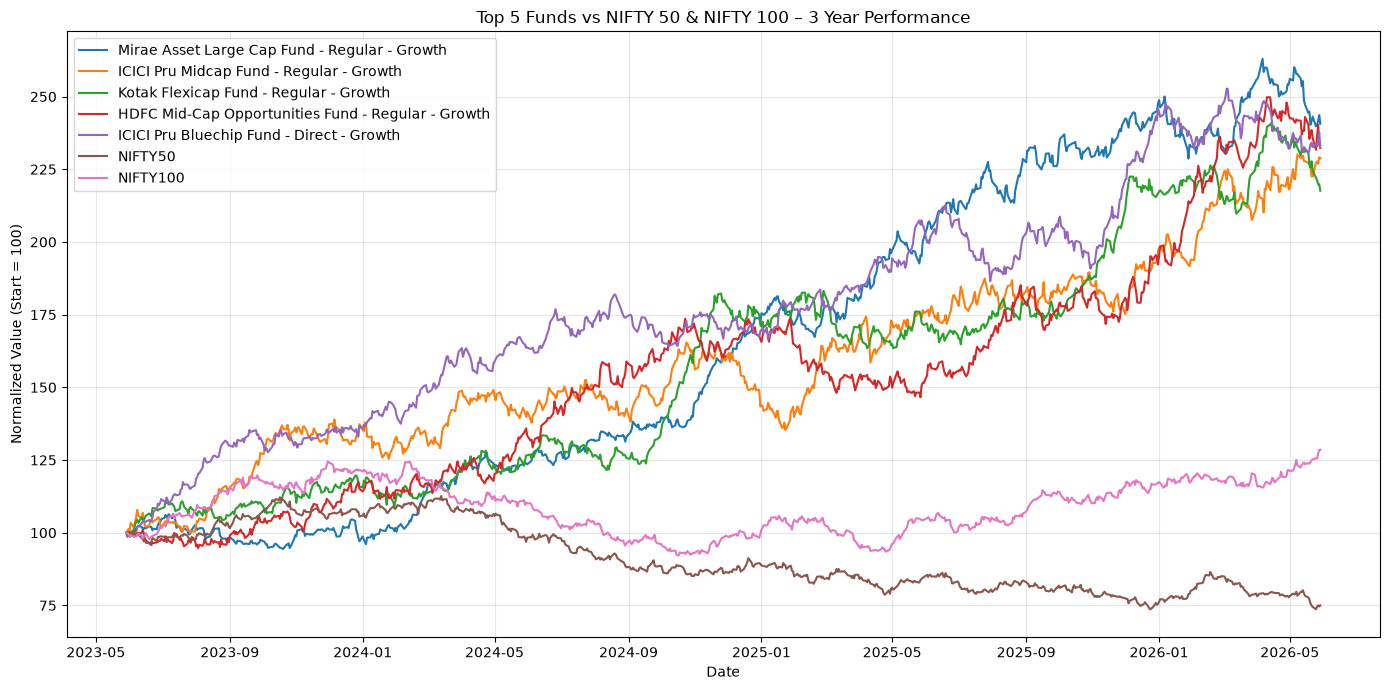

In [45]:
# Top 5 funds vs NIFTY 50 and NIFTY 100
# 3-year normalized performance

comparison_data = []

# Top 5 mutual funds
for _, fund in top5_funds.iterrows():

    fund_data = nav_df[
        (nav_df["amfi_code"] == fund["amfi_code"]) &
        (nav_df["date"] >= start_date) &
        (nav_df["date"] <= end_date)
    ].copy()

    fund_data = fund_data.sort_values("date")

    if len(fund_data) > 0:
        initial_nav = fund_data.iloc[0]["nav"]

        fund_data["normalized_value"] = (
            fund_data["nav"] / initial_nav
        ) * 100

        fund_data["name"] = fund["scheme_name"]

        comparison_data.append(
            fund_data[["date", "name", "normalized_value"]]
        )

# NIFTY 50 and NIFTY 100
for index_name in ["NIFTY50", "NIFTY100"]:

    index_data = benchmark_3y[
        benchmark_3y["index_name"] == index_name
    ].copy()

    index_data = index_data.sort_values("date")

    if len(index_data) > 0:
        initial_value = index_data.iloc[0]["close_value"]

        index_data["normalized_value"] = (
            index_data["close_value"] / initial_value
        ) * 100

        index_data["name"] = index_name

        comparison_data.append(
            index_data[["date", "name", "normalized_value"]]
        )

comparison_df = pd.concat(
    comparison_data,
    ignore_index=True
)

print("Benchmark comparison data prepared!")
print("Series:", comparison_df["name"].nunique())
print("Date range:", comparison_df["date"].min(), "to", comparison_df["date"].max())

plt.figure(figsize=(14, 7))

for name in comparison_df["name"].unique():

    data = comparison_df[
        comparison_df["name"] == name
    ]

    plt.plot(
        data["date"],
        data["normalized_value"],
        label=name
    )

plt.title("Top 5 Funds vs NIFTY 50 & NIFTY 100 – 3 Year Performance")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Start = 100)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [46]:
# Calculate Tracking Error for Top 5 funds against NIFTY 100

tracking_error_results = []

for _, fund in top5_funds.iterrows():

    fund_data = nav_df[
        (nav_df["amfi_code"] == fund["amfi_code"]) &
        (nav_df["date"] >= start_date) &
        (nav_df["date"] <= end_date)
    ][["date", "daily_return"]].dropna()

    merged = pd.merge(
        fund_data,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    # Active return
    merged["active_return"] = (
        merged["daily_return"] -
        merged["benchmark_return"]
    )

    tracking_error = (
        merged["active_return"].std()
        * np.sqrt(TRADING_DAYS)
    )

    tracking_error_results.append({
        "amfi_code": fund["amfi_code"],
        "scheme_name": fund["scheme_name"],
        "tracking_error": tracking_error,
        "tracking_error_pct": tracking_error * 100
    })

tracking_error_df = pd.DataFrame(tracking_error_results)

tracking_error_df = tracking_error_df.round({
    "tracking_error": 4,
    "tracking_error_pct": 2
})

print("Tracking Error calculation completed!")
tracking_error_df

Tracking Error calculation completed!


,amfi_code,scheme_name,tracking_error,tracking_error_pct
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.1879,18.79
1,120505,ICICI Pru Midcap Fund - Regular - Growth,0.2325,23.25
2,120843,Kotak Flexicap Fund - Regular - Growth,0.2064,20.64
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.2248,22.48
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.1873,18.73


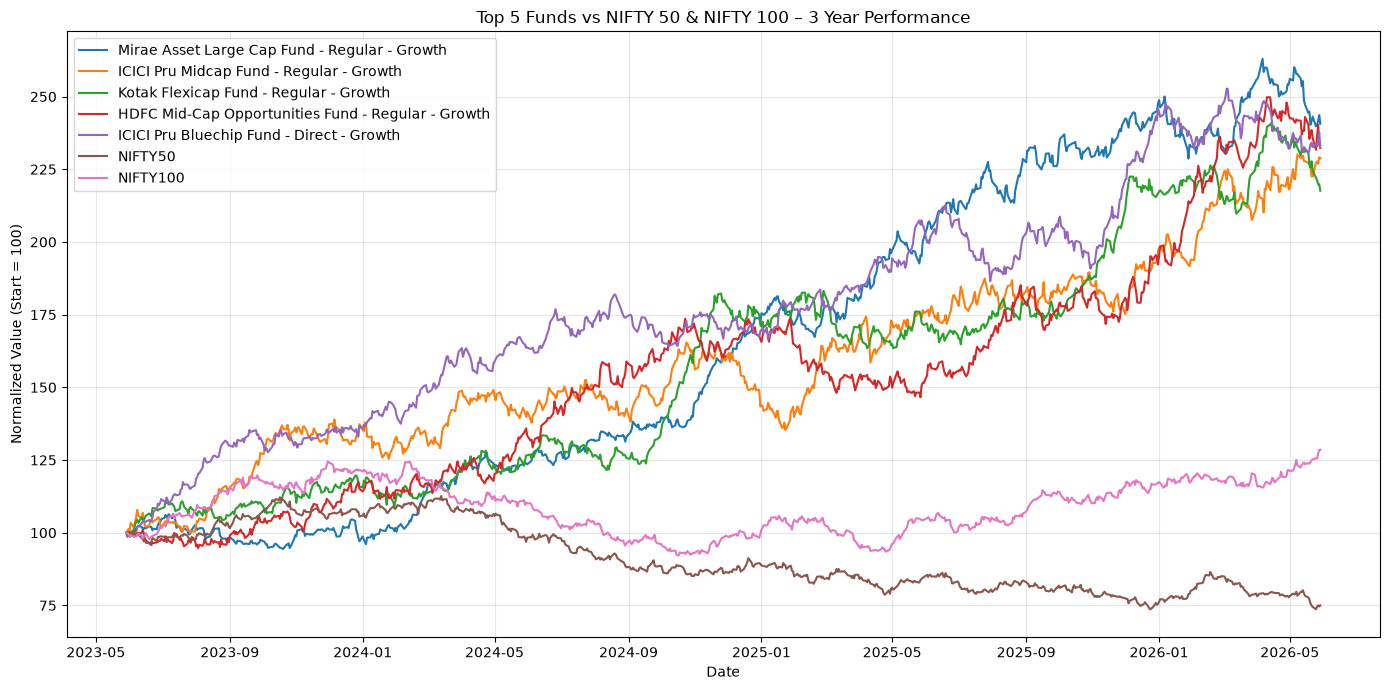

Benchmark comparison chart saved successfully!
File: ..\reports\benchmark_comparison.png


In [47]:
# Save benchmark comparison chart as PNG

chart_file = output_dir / "benchmark_comparison.png"

plt.figure(figsize=(14, 7))

for name in comparison_df["name"].unique():

    data = comparison_df[
        comparison_df["name"] == name
    ]

    plt.plot(
        data["date"],
        data["normalized_value"],
        label=name
    )

plt.title("Top 5 Funds vs NIFTY 50 & NIFTY 100 – 3 Year Performance")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Start = 100)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    chart_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Benchmark comparison chart saved successfully!")
print("File:", chart_file)